# Fake Reviews Dataset - Data Cleaning & EDA

**Dataset:** Salminen et al. (2022) "Amazon Fake Reviews Dataset"
Source: https://osf.io/tyue9/ (Kaggle mirror: "Fake Reviews Dataset")

**What this notebook does:**
1. Loads the raw file and prints its shape/columns (schema can vary slightly between the OSF and Kaggle mirrors, so this auto-detects common column names).
2. Cleans text (basic normalization kept light on purpose; heavier NLP cleaning like stopword removal/lemmatization is done later in modeling, not here, since some signals like punctuation/case can be informative for detecting AI-generated text).
3. Handles missing values and duplicates.
4. Runs EDA: class balance, category distribution, rating distribution, review length distribution, verified-purchase cross-tab (if present).
5. Saves cleaned data + plots to an output folder.

This notebook checks for both and normalizes to a common internal schema.

## Setup

Install requirements (uncomment if running in a fresh environment):

In [1]:
import os
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Configuration

Set the paths for this run.

In [2]:
INPUT_PATH = "data/raw/fake_reviews_dataset.csv"   
OUTPUT_CSV = "data/processed/fake_reviews_cleaned.csv"  
EDA_DIR = "data/eda_outputs"                 


## 1. Load

Load the raw file and report its shape/columns.

In [3]:
df = pd.read_csv(INPUT_PATH)
print(f"Loaded file: {INPUT_PATH}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")

Loaded file: data/raw/fake_reviews_dataset.csv
Shape: (40432, 4)
Columns: ['category', 'rating', 'label', 'text_']



In [4]:
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


## 2. Normalize Schema

Handles both known variants of this dataset (Kaggle mirror vs. OSF/paper version) and standardizes label values to human-readable `fake`/`real`.

In [5]:
df.columns

Index(['category', 'rating', 'label', 'text_'], dtype='object')

In [6]:
df["label"].unique()

array(['CG', 'OR'], dtype=object)

In [7]:
df = df.rename(columns={"text_": "review_text"})

df["label_clean"] = df["label"].map({
    "CG": "fake",
    "OR": "real"
})

df.head()

,category,rating,label,review_text,label_clean
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",fake
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",fake
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,fake
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",fake
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,fake


## 3. Clean

Light text normalization, duplicate/missing-value handling, and a helper `review_word_count` column.

In [8]:
def clean_data(df):
    df = df.copy()

    n_before = len(df)

    # Clean review text
    df["review_text"] = df["review_text"].fillna("").str.strip()
    df["review_text"] = df["review_text"].str.replace(r"\s+", " ", regex=True)
    df["review_text"] = df["review_text"].str.replace(
        r"http\S+|www\.\S+", "", regex=True
    )

    # Remove empty reviews
    df = df[df["review_text"].str.len() > 0]

    # Remove duplicate reviews
    df = df.drop_duplicates(subset=["review_text"])

    # Add word count
    df["review_word_count"] = df["review_text"].str.split().str.len()

    n_after = len(df)

    print(f"Rows before cleaning: {n_before}")
    print(f"Rows after cleaning:  {n_after}")
    print(f"Rows removed:         {n_before - n_after}")

    return df.reset_index(drop=True)

In [9]:
df = clean_data(df)
df.head()


Rows before cleaning: 40432
Rows after cleaning:  40405
Rows removed:         27


,category,rating,label,review_text,label_clean,review_word_count
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfort...",fake,12
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I'...",fake,16
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,fake,14
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",fake,17
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,fake,18


## 4. Exploratory Data Analysis

Class balance, category distribution, rating distribution, review length distribution, and verified-purchase cross-tab (if present). Plots are saved to `EDA_DIR` and also rendered inline below.

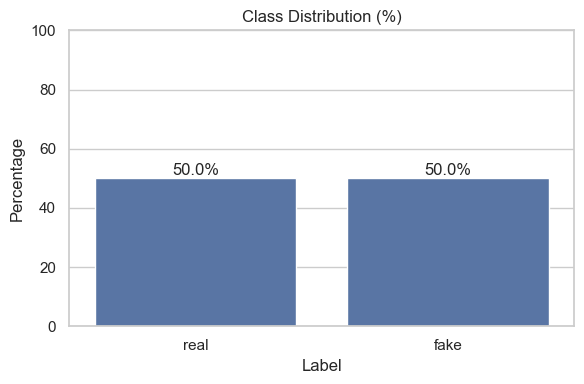

In [10]:
label_pct = df["label_clean"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=label_pct.index, y=label_pct.values)

plt.title("Class Distribution (%)")
plt.xlabel("Label")
plt.ylabel("Percentage")
plt.ylim(0, 100)

for i, value in enumerate(label_pct.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "class_percentage.png"), dpi=150)
plt.show()

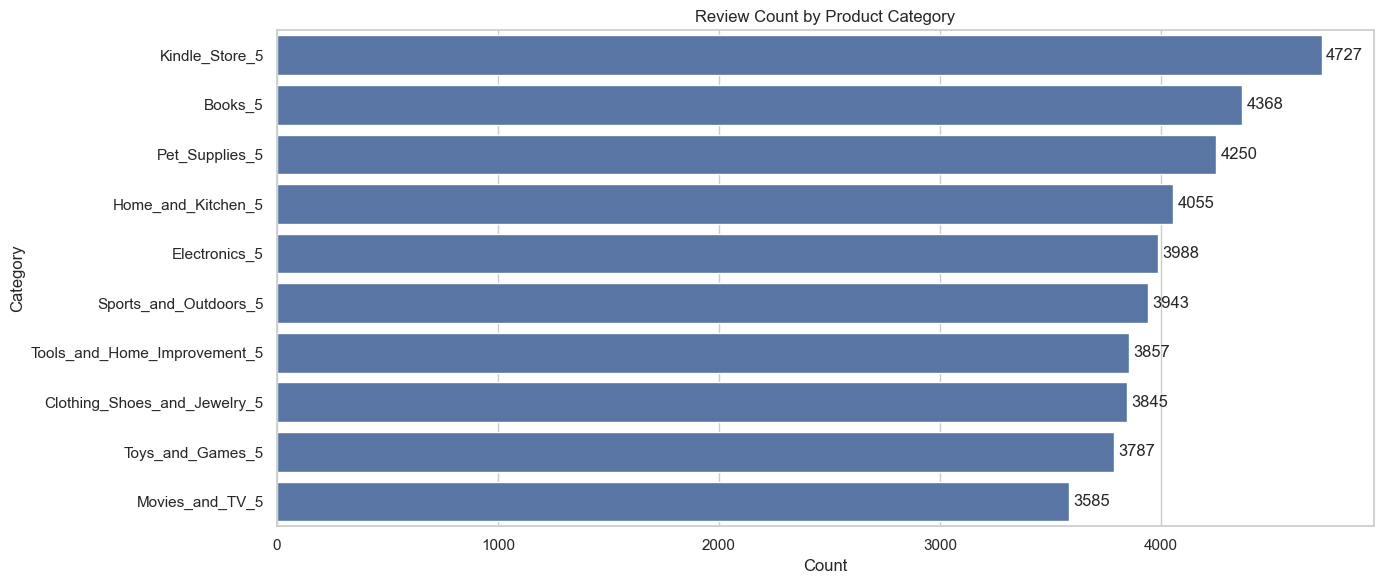

In [12]:
plt.figure(figsize=(14, 6))

top_cats = df["category"].value_counts().head(30)

ax = sns.barplot(
    x=top_cats.values,
    y=top_cats.index
)

plt.title("Review Count by Product Category")
plt.xlabel("Count")
plt.ylabel("Category")

# Add values to bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()

plt.savefig(
    os.path.join(EDA_DIR, "category_distribution.png"),
    dpi=150
)

plt.show()

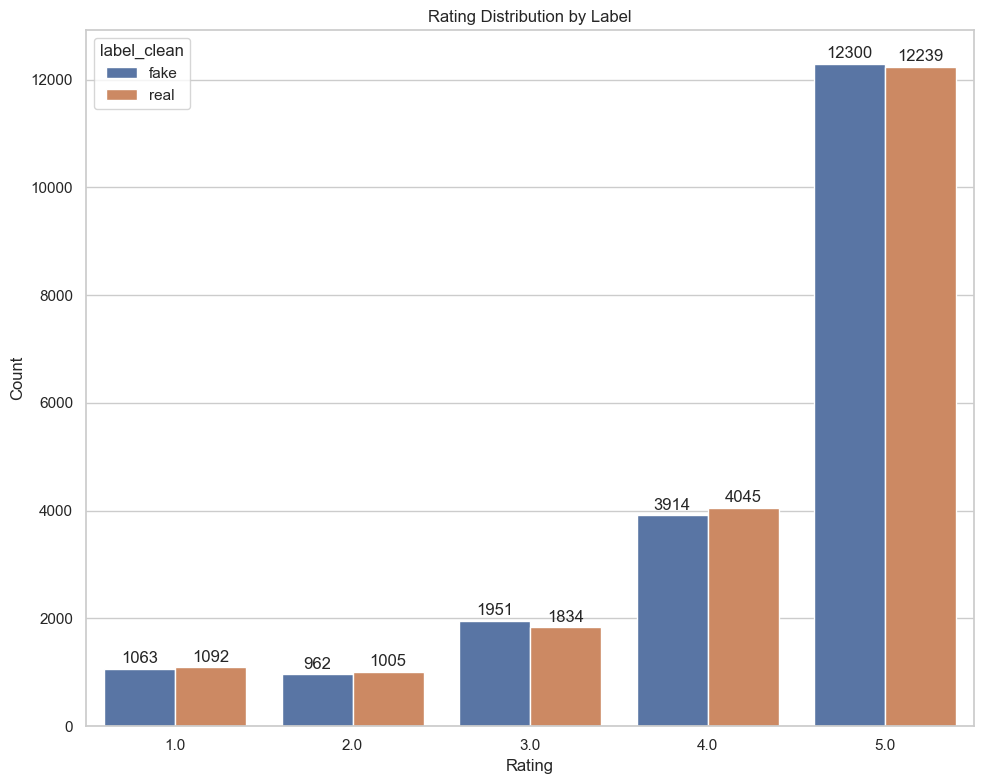

In [13]:
plt.figure(figsize=(10, 8))

ax = sns.countplot(
    data=df,
    x="rating",
    hue="label_clean"
)

plt.title("Rating Distribution by Label")
plt.xlabel("Rating")
plt.ylabel("Count")

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2)

plt.tight_layout()

plt.savefig(
    os.path.join(EDA_DIR, "rating_by_label.png"),
    dpi=150
)

plt.show()

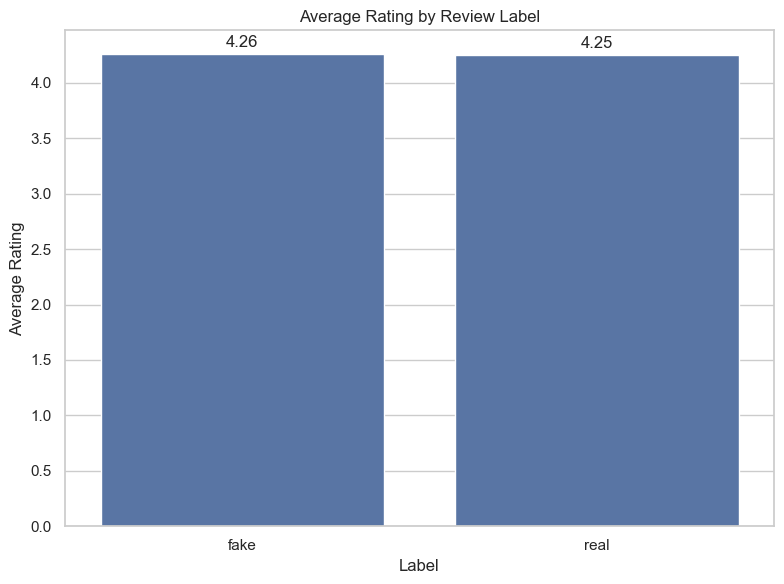

  label_clean    rating
0        fake  4.259336
1        real  4.253228


In [74]:
avg_rating = df.groupby("label_clean")["rating"].mean().reset_index()

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=avg_rating,
    x="label_clean",
    y="rating"
)

plt.title("Average Rating by Review Label")
plt.xlabel("Label")
plt.ylabel("Average Rating")

# Add average rating values
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()

plt.savefig(
    os.path.join(EDA_DIR, "average_rating_by_label.png"),
    dpi=150
)

plt.show()

print(avg_rating)

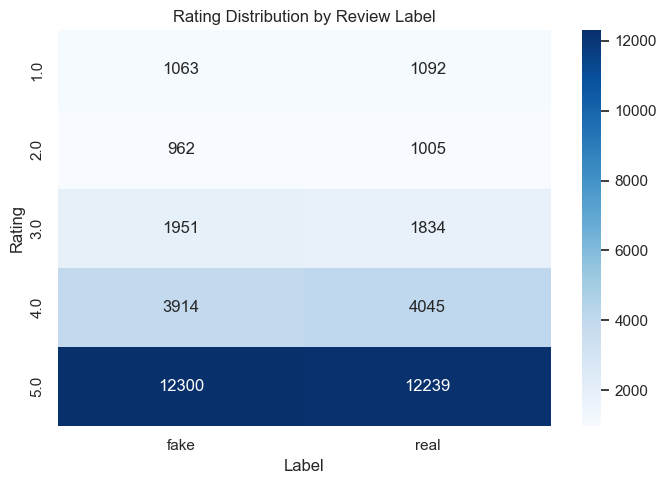

In [75]:
rating_label = pd.crosstab(
    df["rating"],
    df["label_clean"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rating_label,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Rating Distribution by Review Label")
plt.xlabel("Label")
plt.ylabel("Rating")

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "rating_label_heatmap.png"), dpi=150)
plt.show()

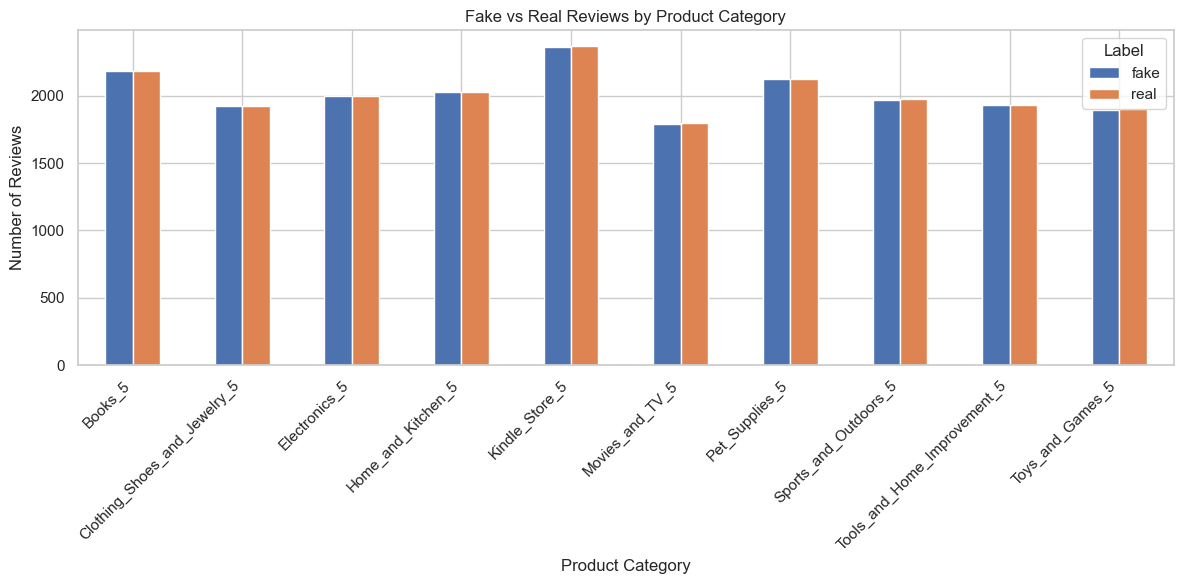

In [76]:
category_label = pd.crosstab(
    df["category"],
    df["label_clean"]
)

top_categories = df["category"].value_counts().head(20).index

category_label = category_label.loc[
    category_label.index.intersection(top_categories)
]

category_label.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Fake vs Real Reviews by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Label")

plt.tight_layout()
plt.savefig(
    os.path.join(EDA_DIR, "category_label_distribution.png"),
    dpi=150
)
plt.show()

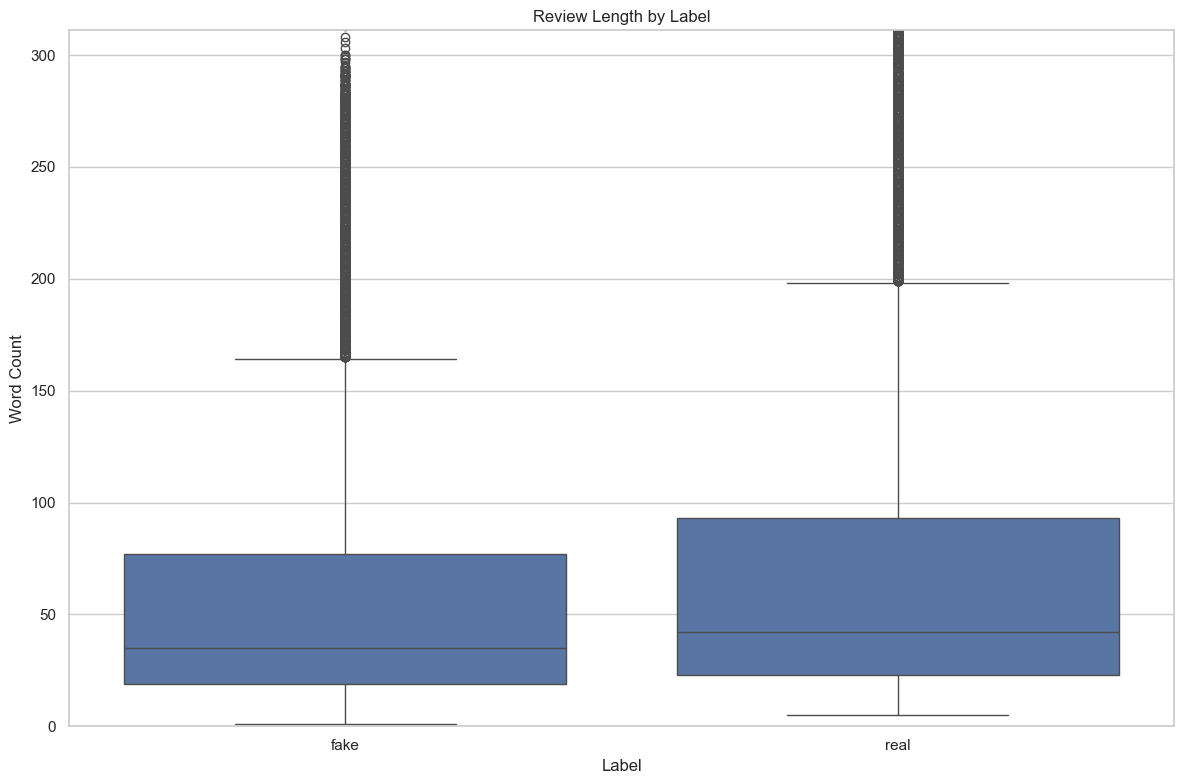

In [14]:
plt.figure(figsize=(12, 8))

sns.boxplot(
    data=df,
    x="label_clean",
    y="review_word_count"
)

plt.title("Review Length by Label")
plt.xlabel("Label")
plt.ylabel("Word Count")

plt.ylim(
    0,
    df["review_word_count"].quantile(0.99)
)

plt.tight_layout()
plt.savefig(
    os.path.join(EDA_DIR, "review_length_boxplot.png"),
    dpi=150
)
plt.show()

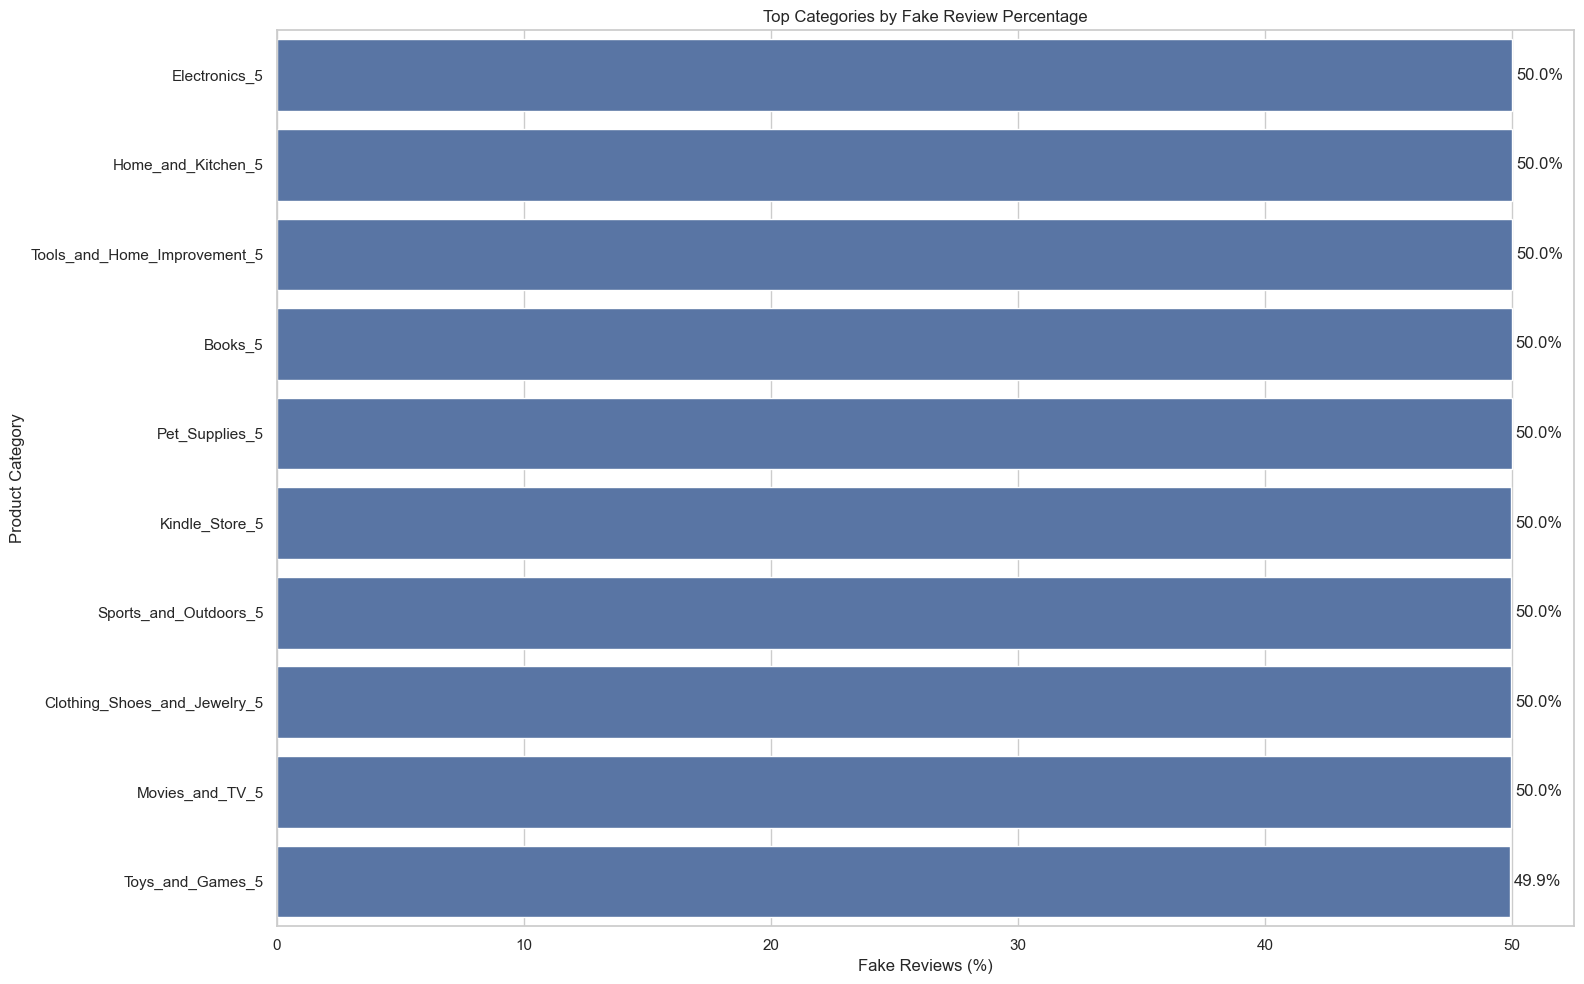

In [78]:
category_fake_rate = (
    df.groupby("category")["label_clean"]
    .apply(lambda x: (x == "fake").mean() * 100)
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(16, 10))

ax = sns.barplot(
    x=category_fake_rate.values,
    y=category_fake_rate.index
)

plt.title("Top Categories by Fake Review Percentage")
plt.xlabel("Fake Reviews (%)")
plt.ylabel("Product Category")

# Add percentage values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    os.path.join(EDA_DIR, "fake_rate_by_category.png"),
    dpi=150
)

plt.show()

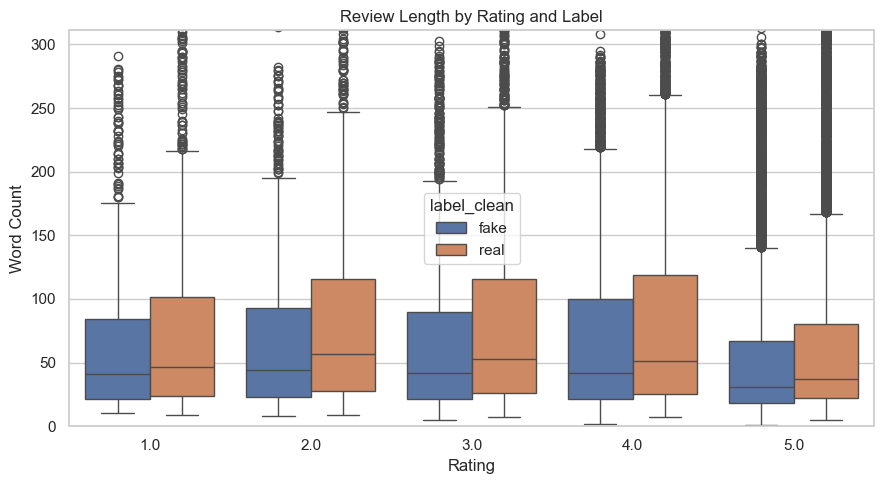

In [79]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="rating",
    y="review_word_count",
    hue="label_clean"
)

plt.title("Review Length by Rating and Label")
plt.xlabel("Rating")
plt.ylabel("Word Count")

plt.ylim(
    0,
    df["review_word_count"].quantile(0.99)
)

plt.tight_layout()
plt.savefig(
    os.path.join(EDA_DIR, "review_length_rating_label.png"),
    dpi=150
)
plt.show()

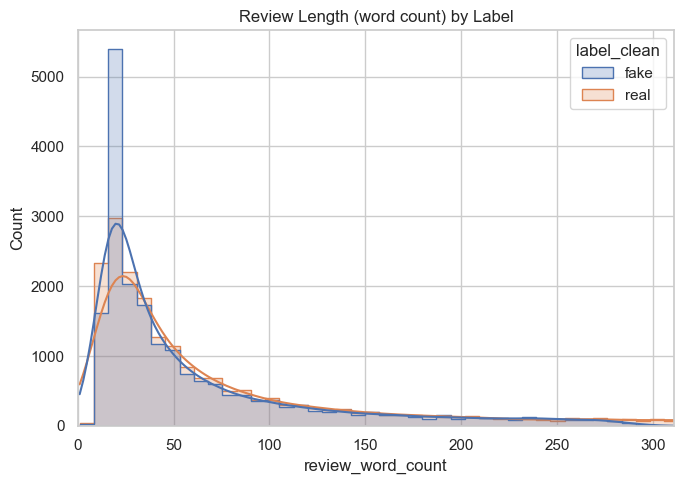

Review word count summary by label:
               count       mean        std  min   25%   50%   75%    max
label_clean                                                             
fake         20190.0  61.330362  61.823433  1.0  19.0  35.0  77.0  318.0
real         20215.0  73.641405  76.078243  5.0  23.0  42.0  93.0  373.0 



In [80]:
plt.figure(figsize=(7, 5))
sns.histplot(
    data=df, x="review_word_count", hue="label_clean",
    bins=50, kde=True, element="step"
)
plt.title("Review Length (word count) by Label")
plt.xlim(0, df["review_word_count"].quantile(0.99))  # trim extreme outliers for readability
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "review_length_by_label.png"), dpi=150)
plt.show()

print("Review word count summary by label:")
print(df.groupby("label_clean")["review_word_count"].describe(), "\n")

## 5. Save Cleaned Dataset

In [81]:
print(df['category'].nunique())
print(df['category'].unique())


10
['Home_and_Kitchen_5' 'Sports_and_Outdoors_5' 'Electronics_5'
 'Movies_and_TV_5' 'Tools_and_Home_Improvement_5' 'Pet_Supplies_5'
 'Kindle_Store_5' 'Books_5' 'Toys_and_Games_5'
 'Clothing_Shoes_and_Jewelry_5']


In [82]:
df.to_csv(OUTPUT_CSV, index=False)
print(f"Cleaned dataset saved to: {OUTPUT_CSV}")


Cleaned dataset saved to: data/processed/fake_reviews_cleaned.csv
